In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
# Better visuals
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6, 6)

# 1. Load & Overview (ALWAYS FIRST STEP)

In [92]:
df = pd.read_csv("./datasets/education_dropout.csv")
df.head(20)

,student_id,age,gender,first_generation_college,international_student,residency_status,high_school_gpa,sat_score,act_score,advanced_courses_taken,...,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,living_arrangement,has_disability,distance_from_campus_miles,work_hours_per_week,dropped_out
0,STU_00000001,23,Male,No,No,In-state,2.88,1034.0,26,2,...,21,0,0,3,0,On-campus,No,64,18,No
1,STU_00000002,20,Male,Yes,No,In-state,2.79,1162.0,20,3,...,11,4,2,1,2,On-campus,No,0,2,Yes
2,STU_00000003,19,Female,No,No,In-state,3.44,1264.0,22,5,...,28,2,2,1,0,On-campus,No,10,5,Yes
3,STU_00000004,17,Male,No,Yes,In-state,2.86,966.0,28,4,...,24,1,0,0,1,Off-campus,No,24,27,No
4,STU_00000005,17,Male,Yes,Yes,Out-of-state,3.77,1174.0,25,8,...,7,7,5,1,0,On-campus,No,15,10,No
5,STU_00000006,22,Female,No,No,In-state,3.25,NaN,23,4,...,7,4,0,3,1,On-campus,No,10,18,No
6,STU_00000007,17,Female,No,No,In-state,3.19,1264.0,19,3,...,25,4,2,0,1,On-campus,No,15,1,No
7,STU_00000008,18,Female,No,No,In-state,3.09,1084.0,30,3,...,2,2,2,0,1,At home,No,34,3,No
8,STU_00000009,17,Male,No,No,In-state,3.20,1006.0,22,2,...,6,1,1,2,1,Commuter,No,7,10,No
9,STU_00000010,17,Male,No,No,In-state,2.92,1384.0,18,8,...,8,4,2,0,3,At home,No,2,8,No


In [93]:
df.dtypes

student_id                               str
age                                    int64
gender                                   str
first_generation_college                 str
international_student                    str
residency_status                         str
high_school_gpa                      float64
sat_score                            float64
act_score                              int64
advanced_courses_taken                 int64
extracurricular_activities             int64
major                                    str
enrollment_status                        str
semester_credits                       int64
admission_type                           str
starting_semester                        str
family_income                            str
financial_aid_received                   str
pell_grant_eligible (scholarship)        str
student_loan_amount                    int64
has_campus_job                           str
current_gpa                          float64
credits_co

In [94]:
df.shape

(15000, 36)

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   student_id                         15000 non-null  str    
 1   age                                15000 non-null  int64  
 2   gender                             15000 non-null  str    
 3   first_generation_college           15000 non-null  str    
 4   international_student              15000 non-null  str    
 5   residency_status                   15000 non-null  str    
 6   high_school_gpa                    15000 non-null  float64
 7   sat_score                          14250 non-null  float64
 8   act_score                          15000 non-null  int64  
 9   advanced_courses_taken             15000 non-null  int64  
 10  extracurricular_activities         15000 non-null  int64  
 11  major                              15000 non-null  str    
 12  e

# 2. Data Quality Checks

In [96]:
# missing values
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

current_gpa                          750
attendance_rate                      750
sat_score                            750
student_id                             0
first_generation_college               0
gender                                 0
age                                    0
international_student                  0
act_score                              0
advanced_courses_taken                 0
residency_status                       0
high_school_gpa                        0
enrollment_status                      0
semester_credits                       0
admission_type                         0
starting_semester                      0
family_income                          0
financial_aid_received                 0
extracurricular_activities             0
major                                  0
student_loan_amount                    0
pell_grant_eligible (scholarship)      0
credits_completed                      0
has_campus_job                         0
courses_failed  

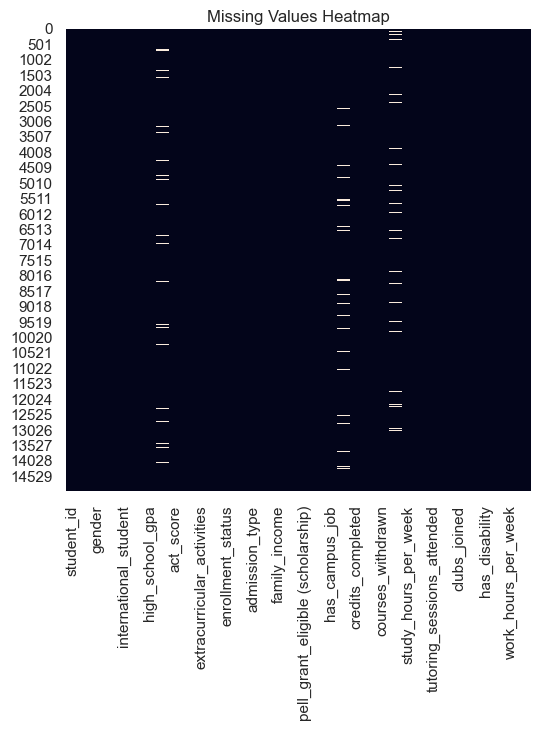

In [97]:
# visualize missing values
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [98]:
# Missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

current_gpa                          5.0
attendance_rate                      5.0
sat_score                            5.0
student_id                           0.0
first_generation_college             0.0
gender                               0.0
age                                  0.0
international_student                0.0
act_score                            0.0
advanced_courses_taken               0.0
residency_status                     0.0
high_school_gpa                      0.0
enrollment_status                    0.0
semester_credits                     0.0
admission_type                       0.0
starting_semester                    0.0
family_income                        0.0
financial_aid_received               0.0
extracurricular_activities           0.0
major                                0.0
student_loan_amount                  0.0
pell_grant_eligible (scholarship)    0.0
credits_completed                    0.0
has_campus_job                       0.0
courses_failed  

In [99]:
# Imputations
df['current_gpa'] = df['current_gpa'].fillna(df['current_gpa'].median())
df['attendance_rate'] = df['attendance_rate'].fillna(df['attendance_rate'].median())
df['sat_score'] = df['sat_score'].fillna(df['sat_score'].median())

In [100]:
# duplicate rows
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# 3. Exploratory Data Analysis - Target Variable & Relationships

In [101]:
df.describe()

,age,high_school_gpa,sat_score,act_score,advanced_courses_taken,extracurricular_activities,semester_credits,student_loan_amount,current_gpa,credits_completed,courses_failed,courses_withdrawn,attendance_rate,study_hours_per_week,library_visits_per_month,tutoring_sessions_attended,advisor_meetings,clubs_joined,distance_from_campus_miles,work_hours_per_week
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.860533,3.287937,1151.856333,23.558733,2.998667,2.508533,13.580200,14962.108667,2.878657,41.503267,0.798733,0.489533,77.734027,11.409267,4.014667,1.988133,1.507133,1.487467,14.430467,9.264800
std,2.521330,0.461853,144.736379,3.919435,1.727599,1.593684,4.055301,15161.711834,0.650274,35.875932,0.900525,0.695933,12.907042,11.673950,2.023015,1.399568,1.236521,1.217679,14.847168,9.142114
min,17.000000,2.000000,800.000000,16.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.970000,1057.000000,21.000000,2.000000,1.000000,12.000000,4273.000000,2.450000,12.000000,0.000000,0.000000,70.200000,3.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000
50%,20.000000,3.310000,1153.000000,23.000000,3.000000,2.000000,15.000000,10188.000000,2.900000,31.000000,1.000000,0.000000,79.800000,8.000000,4.000000,2.000000,1.000000,1.000000,10.000000,6.000000
75%,22.000000,3.640000,1247.000000,26.000000,4.000000,3.000000,18.000000,20691.250000,3.330000,62.000000,1.000000,1.000000,87.400000,16.000000,5.000000,3.000000,2.000000,2.000000,21.000000,13.000000
max,31.000000,4.000000,1600.000000,36.000000,11.000000,10.000000,18.000000,173123.000000,4.000000,120.000000,7.000000,5.000000,99.900000,60.000000,15.000000,9.000000,9.000000,8.000000,100.000000,40.000000


Dropout Distribution:
dropped_out
No     9722
Yes    5278
Name: count, dtype: int64

Dropout Rate (%):
dropped_out
No     64.813333
Yes    35.186667
Name: count, dtype: float64


C:\Users\anshu\AppData\Local\Temp\ipykernel_15892\1811313573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dropped_out', palette='Set2')


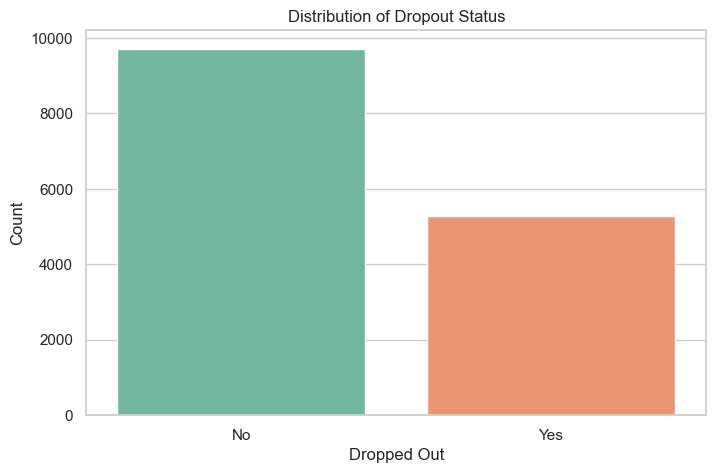

In [102]:
# Target variable distribution
print("Dropout Distribution:")
print(df['dropped_out'].value_counts())
print("\nDropout Rate (%):")
print((df['dropped_out'].value_counts() / len(df)) * 100)

# Visualize target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='dropped_out', palette='Set2')
plt.title('Distribution of Dropout Status')
plt.xlabel('Dropped Out')
plt.ylabel('Count')
plt.show()

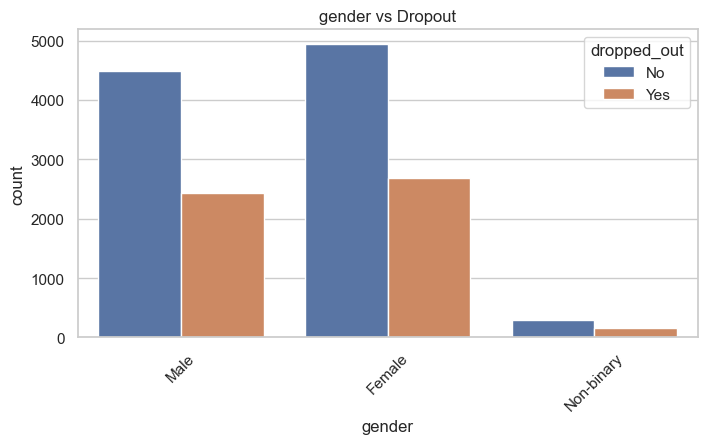

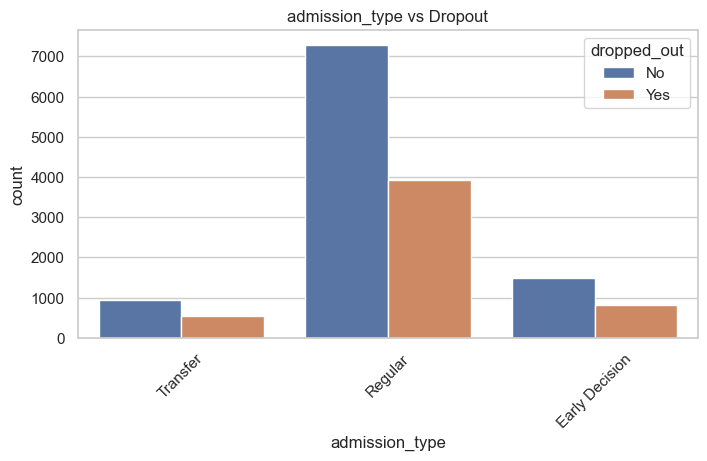

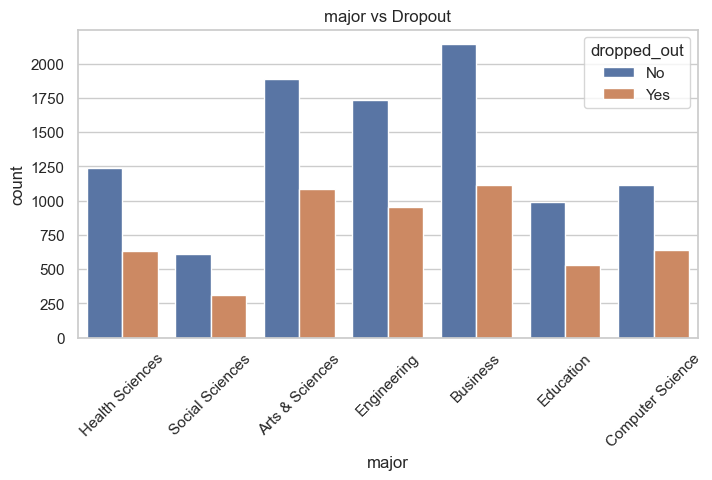

In [103]:
cat_cols = ['gender', 'admission_type', 'major']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='dropped_out', data=df)
    plt.title(f"{col} vs Dropout")
    plt.xticks(rotation=45)
    plt.show()

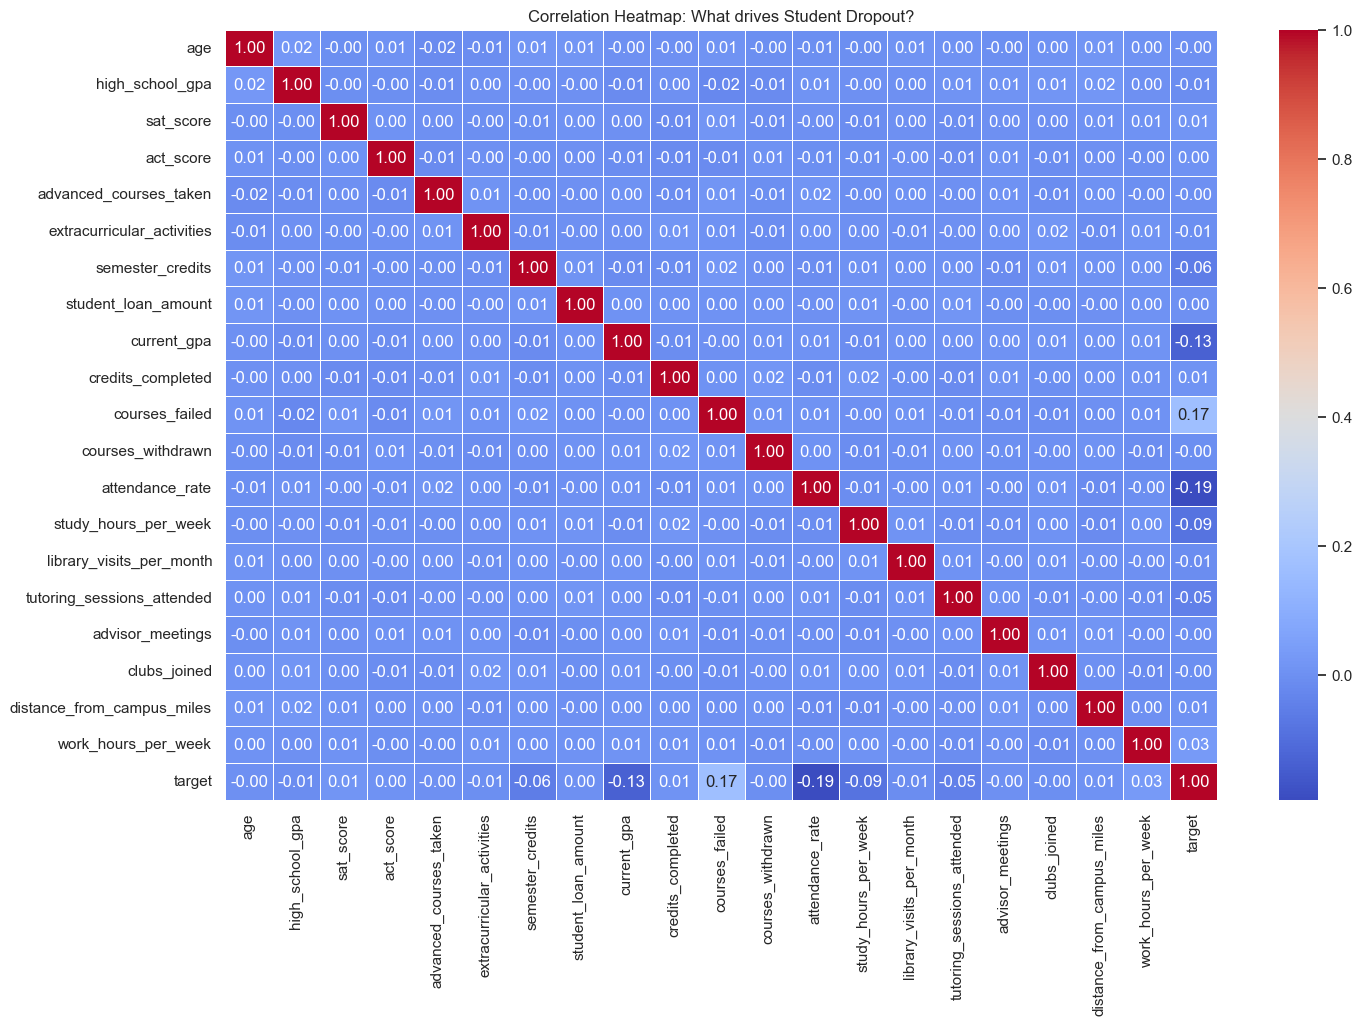

In [104]:
# 1. Convert 'dropped_out' to 1 (Yes) and 0 (No) so it shows up in the correlation
df['target'] = df['dropped_out'].map({'Yes': 1, 'No': 0})

# 2. Select only numerical columns (correlations only work on numbers)
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 3. Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# 4. Create the Heatmap
plt.figure(figsize=(16, 10)) # Big size because you have many columns
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap: What drives Student Dropout?')
plt.show()

In [105]:
num_cols = ['age', 'high_school_gpa', 'sat_score', 'act_score', 'semester_credits',
			'student_loan_amount', 'current_gpa', 'attendance_rate',
			'study_hours_per_week', 'work_hours_per_week', 'gpa_trend',
			'work_to_study_ratio', 'academic_friction']

dropout_rate = df['target'].mean()
print(f"Dropout Rate: {dropout_rate:.2%}")
skewness = df[num_cols].skew().sort_values(ascending=False)
print("Skewness:\n", skewness)

Dropout Rate: 35.19%


KeyError: "['gpa_trend', 'work_to_study_ratio', 'academic_friction'] not in index"

# 4. Feature Engineering

In [ ]:
# Use log1p to handle 0 values safely (log of 0 + 1)
df['log_loan_amount'] = np.log1p(df['student_loan_amount'])

In [ ]:
# 1. Academic Trend: Is their performance slipping?
df['gpa_trend'] = df['current_gpa'] - df['high_school_gpa']

# 2. Time Stress: Balance between work and school
# Adding 1 to denominator to handle students who study 0 hours
df['work_to_study_ratio'] = df['work_hours_per_week'] / (df['study_hours_per_week'] + 1)

# 3. Academic Friction: Ratio of failed/withdrawn courses to total credits
df['academic_friction'] = (df['courses_failed'] + df['courses_withdrawn']) / df['semester_credits']

# 4. Engagement Score: Combining library visits and club participation
df['campus_engagement'] = df['library_visits_per_month'] + df['clubs_joined']

# Preview the new "Engineered" columns
new_features = ['gpa_trend', 'work_to_study_ratio', 'academic_friction', 'campus_engagement']
print(df[['gpa_trend', 'work_to_study_ratio', 'academic_friction', 'campus_engagement']].head())


   gpa_trend  work_to_study_ratio  academic_friction  campus_engagement
0       0.75             0.818182           0.000000                  0
1      -0.87             0.166667           0.277778                  6
2      -1.31             0.172414           0.000000                  2
3       0.36             1.080000           0.055556                  2
4      -0.59             1.250000           0.133333                  7


In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'first_generation_college',
       'international_student', 'residency_status', 'high_school_gpa',
       'sat_score', 'act_score', 'advanced_courses_taken',
       'extracurricular_activities', 'major', 'enrollment_status',
       'semester_credits', 'admission_type', 'starting_semester',
       'family_income', 'financial_aid_received',
       'pell_grant_eligible (scholarship)', 'student_loan_amount',
       'has_campus_job', 'current_gpa', 'credits_completed', 'courses_failed',
       'courses_withdrawn', 'attendance_rate', 'study_hours_per_week',
       'library_visits_per_month', 'tutoring_sessions_attended',
       'advisor_meetings', 'clubs_joined', 'living_arrangement',
       'has_disability', 'distance_from_campus_miles', 'work_hours_per_week',
       'dropped_out', 'target', 'log_loan_amount', 'gpa_trend',
       'work_to_study_ratio', 'academic_friction', 'campus_engagement'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Select the numerical columns that need scaling
# We exclude 'target' and categorical columns
num_cols = ['age', 'high_school_gpa', 'sat_score', 'act_score', 'semester_credits', 
            'student_loan_amount', 'current_gpa', 'attendance_rate', 
            'study_hours_per_week', 'work_hours_per_week', 'gpa_trend', 
            'work_to_study_ratio', 'academic_friction']


# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Fit and Transform the data
# We create a copy to keep the original values for reference if needed
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Check the results
print("--- After Scaling (First 5 rows) ---")
print(df_scaled[num_cols].head())

# Verification: Mean should be ~0 and Std should be ~1
print("\n--- Scaling Check (Mean and Std) ---")
print(f"Mean of SAT Score: {df_scaled['sat_score'].mean():.2f}")
print(f"Std of SAT Score: {df_scaled['sat_score'].std():.2f}")

--- After Scaling (First 5 rows) ---
        age  high_school_gpa  sat_score  act_score  semester_credits  \
0  1.245204        -0.883290  -0.814310   0.622883         -0.389676   
1  0.055317        -1.078163   0.070086  -0.908001          1.089919   
2 -0.341313         0.329257   0.774839  -0.397707         -0.389676   
3 -1.134571        -0.926595  -1.284145   1.133177          1.089919   
4 -1.134571         1.043793   0.152998   0.367735          0.350121   

   student_loan_amount  current_gpa  attendance_rate  study_hours_per_week  \
0            -0.971104     1.155465        -0.320303              0.821577   
1             0.620128    -1.474285        -0.010384             -0.035059   
2             0.221017    -1.151333        -0.606978              1.421223   
3            -0.200783     0.524940         0.469990              1.078568   
4            -0.561506     0.463426         0.160071             -0.377714   

   work_hours_per_week  gpa_trend  work_to_study_ratio  acade

In [ ]:
target_corr = corr_matrix['target'].abs().sort_values(ascending=False)

top_6_features = target_corr.drop(labels=['target']).head(10).index.to_list()


print("--- Top 6 Predictors for Student Dropout ---")
print(top_6_features)

--- Top 6 Predictors for Student Dropout ---
['attendance_rate', 'courses_failed', 'current_gpa', 'study_hours_per_week', 'semester_credits', 'tutoring_sessions_attended', 'work_hours_per_week', 'sat_score', 'library_visits_per_month', 'high_school_gpa']


In [ ]:
# EDA: Numeric features vs Dropout status
# Compare distributions for at-risk (dropped out) vs non-at-risk students
dropout_yes = df[df['dropped_out'] == 'Yes']
dropout_no = df[df['dropped_out'] == 'No']

print(f"Students who dropped out: {len(dropout_yes)}")
print(f"Students who didn't drop out: {len(dropout_no)}")

# Key academic metrics comparison
print("\n=== Academic Metrics Comparison ===")
academic_cols = ['current_gpa', 'sat_score', 'act_score', 'courses_failed', 'courses_withdrawn']
for col in academic_cols:
    print(f"\n{col}:")
    print(f"  Dropped Out   - Mean: {dropout_yes[col].mean():.2f}, Median: {dropout_yes[col].median():.2f}")
    print(f"  Didn't Drop   - Mean: {dropout_no[col].mean():.2f}, Median: {dropout_no[col].median():.2f}")

Students who dropped out: 5278
Students who didn't drop out: 9722

=== Academic Metrics Comparison ===

current_gpa:
  Dropped Out   - Mean: 2.76, Median: 2.84
  Didn't Drop   - Mean: 2.94, Median: 2.90

sat_score:
  Dropped Out   - Mean: 1154.43, Median: 1153.00
  Didn't Drop   - Mean: 1150.46, Median: 1153.00

act_score:
  Dropped Out   - Mean: 23.58, Median: 24.00
  Didn't Drop   - Mean: 23.55, Median: 23.00

courses_failed:
  Dropped Out   - Mean: 1.00, Median: 1.00
  Didn't Drop   - Mean: 0.69, Median: 1.00

courses_withdrawn:
  Dropped Out   - Mean: 0.49, Median: 0.00
  Didn't Drop   - Mean: 0.49, Median: 0.00


C:\Users\anshu\AppData\Local\Temp\ipykernel_15892\925456764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dropped_out', y=feature, ax=axes[idx], palette='Set2')
C:\Users\anshu\AppData\Local\Temp\ipykernel_15892\925456764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dropped_out', y=feature, ax=axes[idx], palette='Set2')
C:\Users\anshu\AppData\Local\Temp\ipykernel_15892\925456764.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dropped_out', y=feature, ax=axes[idx], palette='Set2')
C:\User

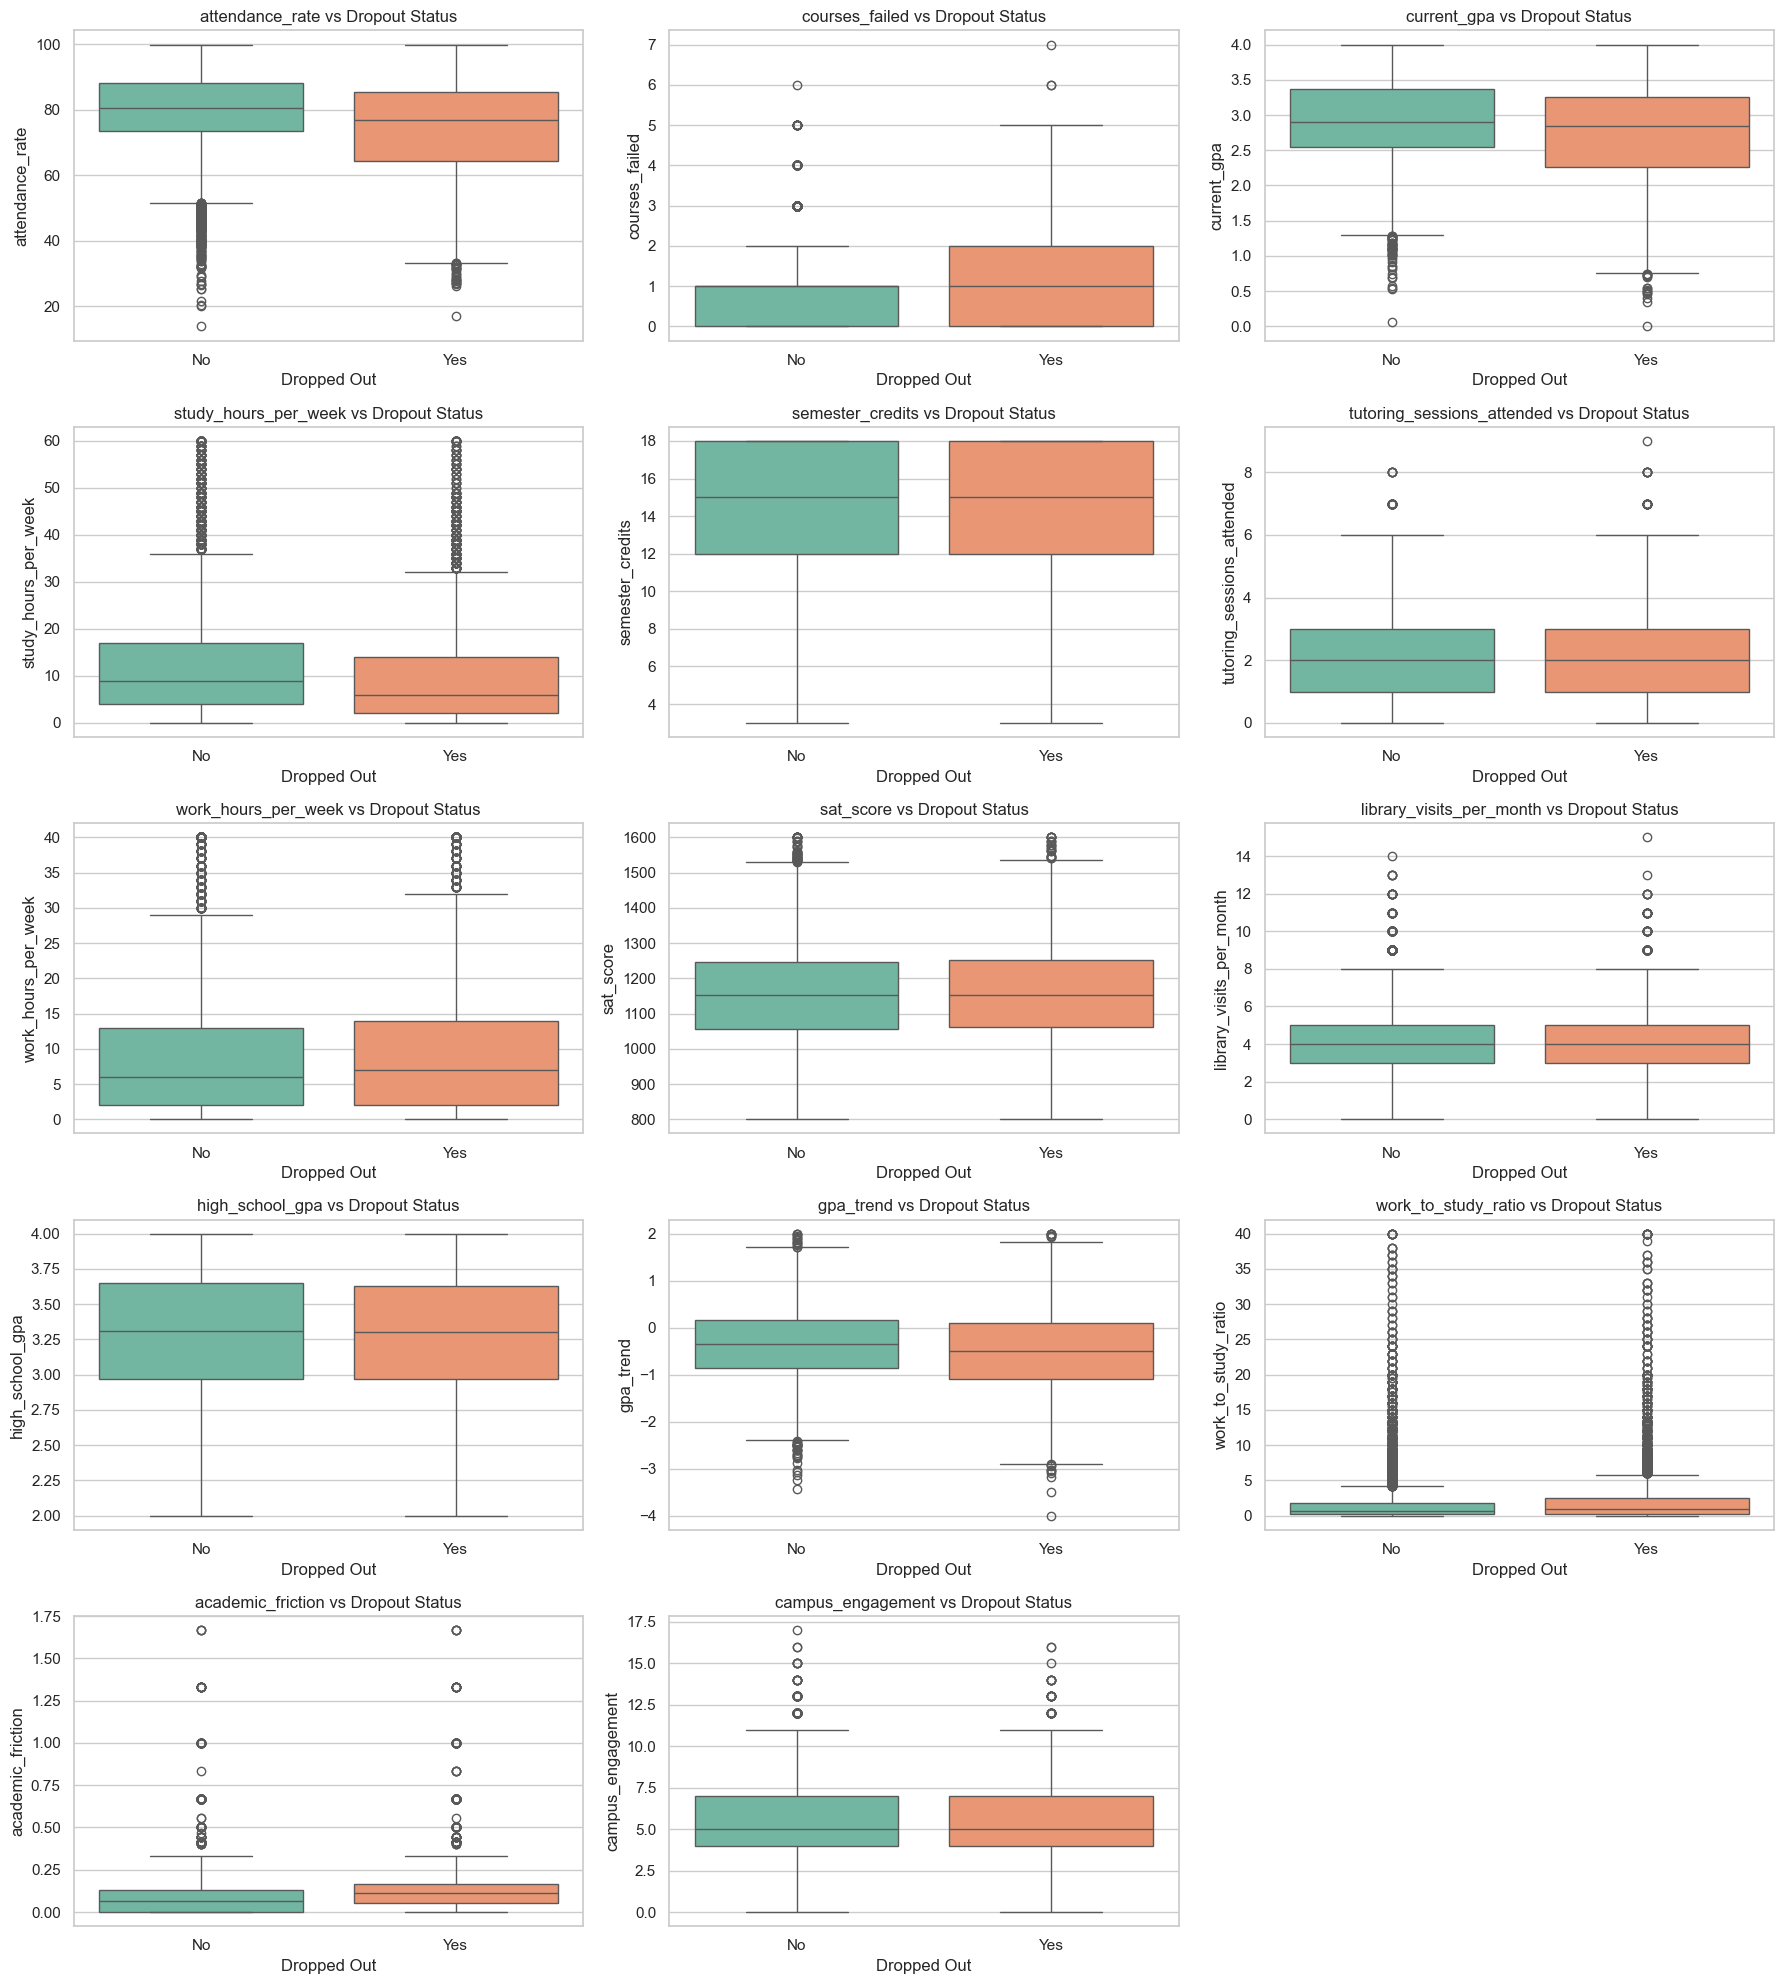

In [ ]:
# 1. Your list of 6 features
features_to_plot = top_6_features + new_features

# 2. Create a grid large enough (5 rows * 3 columns = 15 slots for 14 features)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Flatten turns the 5x3 matrix into a simple list of 15 slots

# 3. Loop through and plot
for idx, feature in enumerate(features_to_plot):
    sns.boxplot(data=df, x='dropped_out', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} vs Dropout Status')
    axes[idx].set_xlabel('Dropped Out')

# 4. Hide the empty slots (we have 14 features, so hide slots 14 and 15)
axes[14].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
## Deal with Outliers
# Cap Study Hours at 40 (anyone above 40 becomes 40)
df['study_hours_per_week'] = df['study_hours_per_week'].clip(upper=40)

# Cap Work Hours at 40
df['work_hours_per_week'] = df['work_hours_per_week'].clip(upper=40)

# 5. Hypothesis Testing - Statistical Significance

## Numerical Data

In [ ]:

from scipy import stats

# 1. Define the specific columns you want to test
target_features = top_6_features + new_features

significant_features = []
results = []

from scipy.stats import mannwhitneyu, shapiro

alpha = 0.05
adjusted_alpha = alpha / len(target_features)

for feature in target_features:
    if feature in df.columns:
        dropped = df[df['dropped_out'] == 'Yes'][feature].dropna()
        not_dropped = df[df['dropped_out'] == 'No'][feature].dropna()
        
        # Normality test
        _, p_norm = shapiro(dropped.sample(min(500, len(dropped))))
        
        # Use robust test
        stat, p_value = mannwhitneyu(dropped, not_dropped)
        
        if p_value < adjusted_alpha:
            print(f"✓ {feature} | Significant (p={p_value:.5f})")
        else:
            print(f"✗ {feature} | Not Significant (p={p_value:.5f})")

✓ attendance_rate | Significant (p=0.00000)
✓ courses_failed | Significant (p=0.00000)
✓ current_gpa | Significant (p=0.00000)
✓ study_hours_per_week | Significant (p=0.00000)
✓ semester_credits | Significant (p=0.00000)
✓ tutoring_sessions_attended | Significant (p=0.00000)
✗ work_hours_per_week | Not Significant (p=0.01500)
✗ sat_score | Not Significant (p=0.12750)
✗ library_visits_per_month | Not Significant (p=0.34682)
✗ high_school_gpa | Not Significant (p=0.34097)
✓ gpa_trend | Significant (p=0.00000)
✓ work_to_study_ratio | Significant (p=0.00000)
✓ academic_friction | Significant (p=0.00000)
✗ campus_engagement | Not Significant (p=0.31755)


## Categorical Data

In [ ]:
from scipy.stats import chi2_contingency

cat_cols = ['gender', 'admission_type', 'major']

for col in cat_cols:
    cont_table = pd.crosstab(df[col], df['dropped_out'])
    chi2, p, _, _ = chi2_contingency(cont_table)
    
    if p < adjusted_alpha:
            print(f"✓ {col} | Significant (p={p:.5f})")
    else:
            print(f"✗ {col} | Not Significant (p={p:.5f})")

✗ gender | Not Significant (p=0.99201)
✗ admission_type | Not Significant (p=0.61885)
✗ major | Not Significant (p=0.33920)


In [ ]:
df[cat_cols]

,gender,admission_type,major
0,Male,Transfer,Health Sciences
1,Male,Regular,Social Sciences
2,Female,Regular,Arts & Sciences
3,Male,Regular,Engineering
4,Male,Early Decision,Business
...,...,...,...
14995,Non-binary,Regular,Education
14996,Male,Regular,Business
14997,Male,Regular,Education
14998,Male,Early Decision,Health Sciences


# 6. Feature Selection

In [ ]:
# Get categorical columns (excluding student_id and target)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'student_id' in categorical_cols: categorical_cols.remove('student_id')
if 'dropped_out' in categorical_cols: categorical_cols.remove('dropped_out')

# 2. Combine and Encode
X = pd.get_dummies(df[significant_features], drop_first=True)
y = df['target'] # This is our 0 and 1 dropout label

# 3. Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

C:\Users\anshu\AppData\Local\Temp\ipykernel_15892\1428340526.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Training set size: (12000, 10)
Testing set size: (3000, 10)


In [ ]:
X

,attendance_rate,courses_failed,current_gpa,study_hours_per_week,semester_credits,tutoring_sessions_attended,work_hours_per_week,gpa_trend,work_to_study_ratio,academic_friction
0,73.6,0,3.63,21,12,0,18,0.75,0.818182,0.000000
1,77.6,2,1.92,11,18,2,2,-0.87,0.166667,0.277778
2,69.9,0,2.13,28,12,2,5,-1.31,0.172414,0.000000
3,83.8,0,3.22,24,18,0,27,0.36,1.080000,0.055556
4,79.8,1,3.18,7,15,5,10,-0.59,1.250000,0.133333
...,...,...,...,...,...,...,...,...,...,...
14995,99.2,0,3.25,18,9,0,13,0.05,0.684211,0.111111
14996,88.4,1,2.90,4,15,1,13,-0.13,2.600000,0.133333
14997,75.9,1,3.42,1,15,5,3,-0.04,1.500000,0.200000
14998,90.0,1,2.90,0,12,3,0,-0.71,0.000000,0.083333


# 7. Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Random Forest
# n_estimators=100 means we are building 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Train (Fit) the model using your training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the hidden test data
y_pred = rf_model.predict(X_test)

# 4. Evaluate the results
print("--- Model Accuracy ---")
print(f"{accuracy_score(y_test, y_pred):.2%}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
70.93%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.73      0.88      0.80      1944
           1       0.64      0.40      0.49      1056

    accuracy                           0.71      3000
   macro avg       0.68      0.64      0.65      3000
weighted avg       0.70      0.71      0.69      3000

